
# Premier League Competitiveness Analysis  
## Title Race, Top 4 Race, and Relegation Survival

### Project Goal

This project uses Premier League table data from **1992-93 to 2025-26** to study how competitiveness has changed over time.

The analysis focuses on three major battles in the league table:

1. **Title Race** — 1st vs 2nd  
2. **Top 4 Race** — 4th vs 5th  
3. **Relegation Survival** — 17th vs 18th  

### Important Data Note

The early Premier League seasons had **42 matches**, while modern seasons have **38 matches**.  
To make seasons comparable, points are normalized using:

```text
Points Per Game = Points / Matches Played
38-Match Equivalent = Points Per Game × 38
```

The incomplete **2025-26** season is excluded from the main historical analysis.



# 1. Import Libraries


In [1]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)



# 2. Load the Dataset


In [2]:

df = pd.read_csv(r'C:\Users\USER\OneDrive\Desktop\premier_league_table_1993_to_2026.csv')

df.head()


,pos,team,pld,w,d,l,gf,ga,gd,pts,season
0,1,Manchester United,42,24,12,6,67,31,36,84,1992-93
1,2,Aston Villa,42,21,11,10,57,40,17,74,1992-93
2,3,Norwich City,42,21,9,12,61,65,4,72,1992-93
3,4,Blackburn Rovers,42,20,11,11,68,46,22,71,1992-93
4,5,Queens Park Rangers,42,17,12,13,63,55,8,63,1992-93



# 3. Inspect the Dataset

This step checks the structure, columns, data types, and missing values.


In [3]:

print("Rows and columns:", df.shape)

print("\nColumns:")
print(df.columns)

print("\nData types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())


Rows and columns: (686, 11)

Columns:
Index(['pos', 'team', 'pld', 'w', 'd', 'l', 'gf', 'ga', 'gd', 'pts', 'season'], dtype='object')

Data types:
pos        int64
team      object
pld        int64
w          int64
d          int64
l          int64
gf         int64
ga         int64
gd         int64
pts        int64
season    object
dtype: object

Missing values:
pos       0
team      0
pld       0
w         0
d         0
l         0
gf        0
ga        0
gd        0
pts       0
season    0
dtype: int64



# 4. Check Season Format and Completeness

Some seasons had 42 matches, while the current 2025-26 season is incomplete.  
This section checks how many teams and matches are recorded in each season.


In [4]:

season_summary = (
    df.groupby("season")
      .agg(
          teams=("team", "count"),
          min_matches_played=("pld", "min"),
          max_matches_played=("pld", "max")
      )
      .reset_index()
)

season_summary.head(10)


,season,teams,min_matches_played,max_matches_played
0,1992-93,22,42,42
1,1993-94,22,42,42
2,1994-95,22,42,42
3,1995-96,20,38,38
4,1996-97,20,38,38
5,1997-98,20,38,38
6,1998-99,20,38,38
7,1999-2000,20,38,38
8,2000-01,20,38,38
9,2001-02,20,38,38


In [5]:

season_summary.tail(10)


,season,teams,min_matches_played,max_matches_played
24,2016-17,20,38,38
25,2017-18,20,38,38
26,2018-19,20,38,38
27,2019-20,20,38,38
28,2020-21,20,38,38
29,2021-22,20,38,38
30,2022-23,20,38,38
31,2023-24,20,38,38
32,2024-25,20,38,38
33,2025-26,20,31,32



# 5. Create Clean Working Dataset

New columns created:

- `season_start`: first year of the season
- `season_end`: second year of the season
- `is_complete_season`: identifies completed seasons


In [6]:

df_clean = df.copy()

df_clean["season_start"] = df_clean["season"].str[:4].astype(int)
df_clean["season_end"] = df_clean["season_start"] + 1

# A season is complete if every team has played at least 38 matches.
# This keeps early 42-match seasons but removes incomplete current seasons.
df_clean["is_complete_season"] = (
    df_clean.groupby("season")["pld"].transform("min") >= 38
)

df_clean[["season", "team", "pos", "pld", "pts", "season_start", "is_complete_season"]].tail(10)


,season,team,pos,pld,pts,season_start,is_complete_season
676,2025-26,Bournemouth,11,32,45,2025,False
677,2025-26,Fulham,12,32,44,2025,False
678,2025-26,Crystal Palace,13,31,42,2025,False
679,2025-26,Newcastle United,14,32,42,2025,False
680,2025-26,Leeds United,15,32,36,2025,False
681,2025-26,Nottingham Forest,16,32,33,2025,False
682,2025-26,West Ham United,17,32,32,2025,False
683,2025-26,Tottenham Hotspur,18,32,30,2025,False
684,2025-26,Burnley,19,32,20,2025,False
685,2025-26,Wolverhampton Wanderers,20,32,17,2025,False


In [7]:

complete_df = df_clean[df_clean["is_complete_season"]].copy()

print("Original rows:", len(df_clean))
print("Rows after removing incomplete seasons:", len(complete_df))
print("Incomplete seasons removed:")
print(df_clean.loc[~df_clean["is_complete_season"], "season"].unique())


Original rows: 686
Rows after removing incomplete seasons: 666
Incomplete seasons removed:
['2025-26']



# 6. Create Era Categories

The first three seasons are separated because they used the 22-team, 42-match format.


In [8]:

def assign_era(season_start):
    if season_start <= 1994:
        return "22-Team Early EPL Era (1992-93 to 1994-95)"
    elif season_start <= 2002:
        return "20-Team Early EPL Era (1995-96 to 2002-03)"
    elif season_start <= 2012:
        return "Big Four / Transition Era (2003-04 to 2012-13)"
    else:
        return "Modern Competitive Era (2013-14 to 2024-25)"

complete_df["era"] = complete_df["season_start"].apply(assign_era)

complete_df[["season", "team", "pos", "pld", "pts", "era"]].head()


,season,team,pos,pld,pts,era
0,1992-93,Manchester United,1,42,84,22-Team Early EPL Era (1992-93 to 1994-95)
1,1992-93,Aston Villa,2,42,74,22-Team Early EPL Era (1992-93 to 1994-95)
2,1992-93,Norwich City,3,42,72,22-Team Early EPL Era (1992-93 to 1994-95)
3,1992-93,Blackburn Rovers,4,42,71,22-Team Early EPL Era (1992-93 to 1994-95)
4,1992-93,Queens Park Rangers,5,42,63,22-Team Early EPL Era (1992-93 to 1994-95)



# 7. Top 4 Race Analysis

## Question

**How many points are usually needed to finish in the Top 4?**

The key position is **4th place**, because it represents the Top 4 threshold.


In [9]:

top4_threshold = (
    complete_df[complete_df["pos"] == 4]
    [["season", "season_start", "team", "pld", "pts", "era"]]
    .rename(columns={
        "team": "fourth_place_team",
        "pld": "matches_played",
        "pts": "top4_points"
    })
    .reset_index(drop=True)
)

top4_threshold["top4_ppg"] = (
    top4_threshold["top4_points"] / top4_threshold["matches_played"]
)

top4_threshold["top4_points_38_equivalent"] = (
    top4_threshold["top4_ppg"] * 38
)

top4_threshold.head()


,season,season_start,fourth_place_team,matches_played,top4_points,era,top4_ppg,top4_points_38_equivalent
0,1992-93,1992,Blackburn Rovers,42,71,22-Team Early EPL Era (1992-93 to 1994-95),1.690476,64.238095
1,1993-94,1993,Arsenal,42,71,22-Team Early EPL Era (1992-93 to 1994-95),1.690476,64.238095
2,1994-95,1994,Liverpool,42,74,22-Team Early EPL Era (1992-93 to 1994-95),1.761905,66.952381
3,1995-96,1995,Aston Villa,38,63,20-Team Early EPL Era (1995-96 to 2002-03),1.657895,63.000000
4,1996-97,1996,Liverpool,38,68,20-Team Early EPL Era (1995-96 to 2002-03),1.789474,68.000000



## Add 5th Place Comparison

The gap between **4th and 5th** shows how tight the Top 4 race was.


In [10]:

fifth_place = (
    complete_df[complete_df["pos"] == 5]
    [["season", "team", "pts"]]
    .rename(columns={
        "team": "fifth_place_team",
        "pts": "fifth_place_points"
    })
)

top4_metrics = (
    top4_threshold
    .merge(fifth_place, on="season")
)

top4_metrics["top4_gap"] = (
    top4_metrics["top4_points"] - top4_metrics["fifth_place_points"]
)

top4_metrics["top4_gap_38_equivalent"] = (
    top4_metrics["top4_points_38_equivalent"] -
    ((top4_metrics["fifth_place_points"] / top4_metrics["matches_played"]) * 38)
)

top4_metrics["top4_rolling_avg_5yr"] = (
    top4_metrics["top4_points_38_equivalent"]
    .rolling(window=5, min_periods=1)
    .mean()
)

top4_metrics.head()


,season,season_start,fourth_place_team,matches_played,top4_points,era,top4_ppg,top4_points_38_equivalent,fifth_place_team,fifth_place_points,top4_gap,top4_gap_38_equivalent,top4_rolling_avg_5yr
0,1992-93,1992,Blackburn Rovers,42,71,22-Team Early EPL Era (1992-93 to 1994-95),1.690476,64.238095,Queens Park Rangers,63,8,7.238095,64.238095
1,1993-94,1993,Arsenal,42,71,22-Team Early EPL Era (1992-93 to 1994-95),1.690476,64.238095,Leeds United,70,1,0.904762,64.238095
2,1994-95,1994,Liverpool,42,74,22-Team Early EPL Era (1992-93 to 1994-95),1.761905,66.952381,Leeds United,73,1,0.904762,65.142857
3,1995-96,1995,Aston Villa,38,63,20-Team Early EPL Era (1995-96 to 2002-03),1.657895,63.000000,Arsenal,63,0,0.000000,64.607143
4,1996-97,1996,Liverpool,38,68,20-Team Early EPL Era (1995-96 to 2002-03),1.789474,68.000000,Aston Villa,61,7,7.000000,65.285714


In [11]:

top4_era_summary = (
    top4_metrics.groupby("era")
    .agg(
        seasons=("season", "count"),
        average_top4_points=("top4_points", "mean"),
        average_top4_38_equivalent=("top4_points_38_equivalent", "mean"),
        lowest_top4_38_equivalent=("top4_points_38_equivalent", "min"),
        highest_top4_38_equivalent=("top4_points_38_equivalent", "max"),
        average_gap_to_5th=("top4_gap", "mean")
    )
    .round(2)
    .reset_index()
)

top4_era_summary


,era,seasons,average_top4_points,average_top4_38_equivalent,lowest_top4_38_equivalent,highest_top4_38_equivalent,average_gap_to_5th
0,20-Team Early EPL Era (1995-96 to 2002-03),8,66.75,66.75,63.00,71.00,4.12
1,22-Team Early EPL Era (1992-93 to 1994-95),3,72.00,65.14,64.24,66.95,3.33
2,Big Four / Transition Era (2003-04 to 2012-13),10,68.40,68.40,60.00,76.00,5.10
3,Modern Competitive Era (2013-14 to 2024-25),12,70.75,70.75,66.00,79.00,3.00



## Top 4 Visualizations


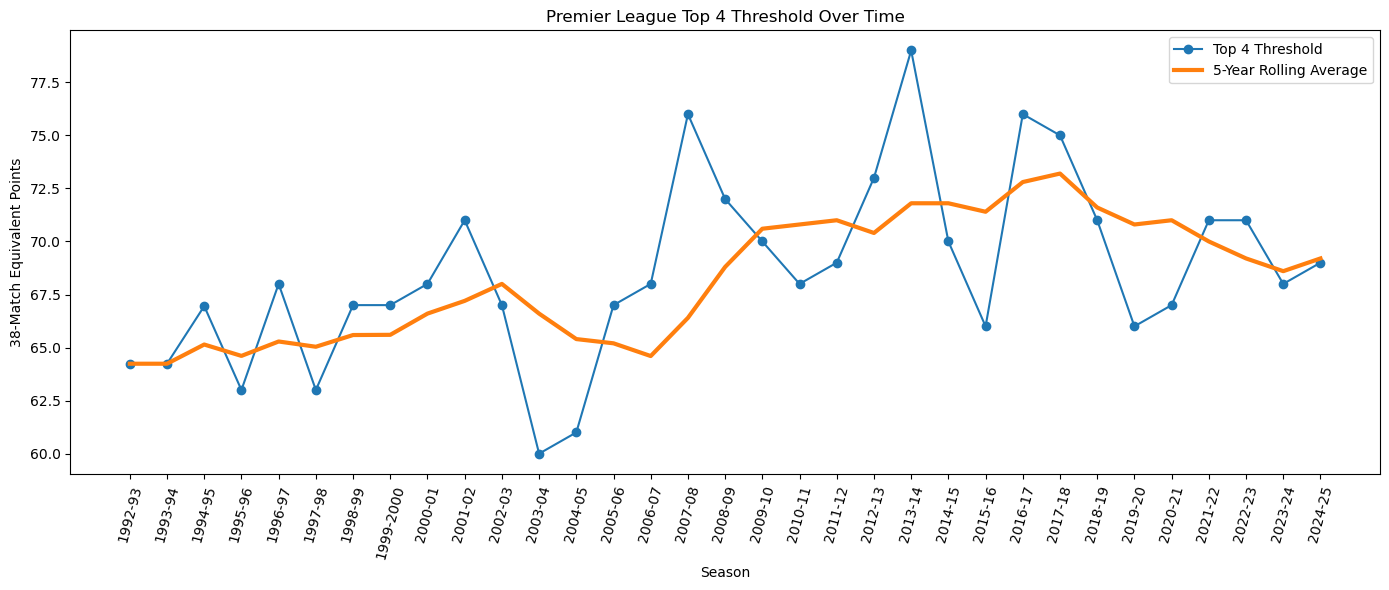

In [12]:

plt.figure(figsize=(14, 6))

plt.plot(
    top4_metrics["season"],
    top4_metrics["top4_points_38_equivalent"],
    marker="o",
    label="Top 4 Threshold"
)

plt.plot(
    top4_metrics["season"],
    top4_metrics["top4_rolling_avg_5yr"],
    linewidth=3,
    label="5-Year Rolling Average"
)

plt.title("Premier League Top 4 Threshold Over Time")
plt.xlabel("Season")
plt.ylabel("38-Match Equivalent Points")
plt.xticks(rotation=75)
plt.legend()
plt.tight_layout()
plt.show()


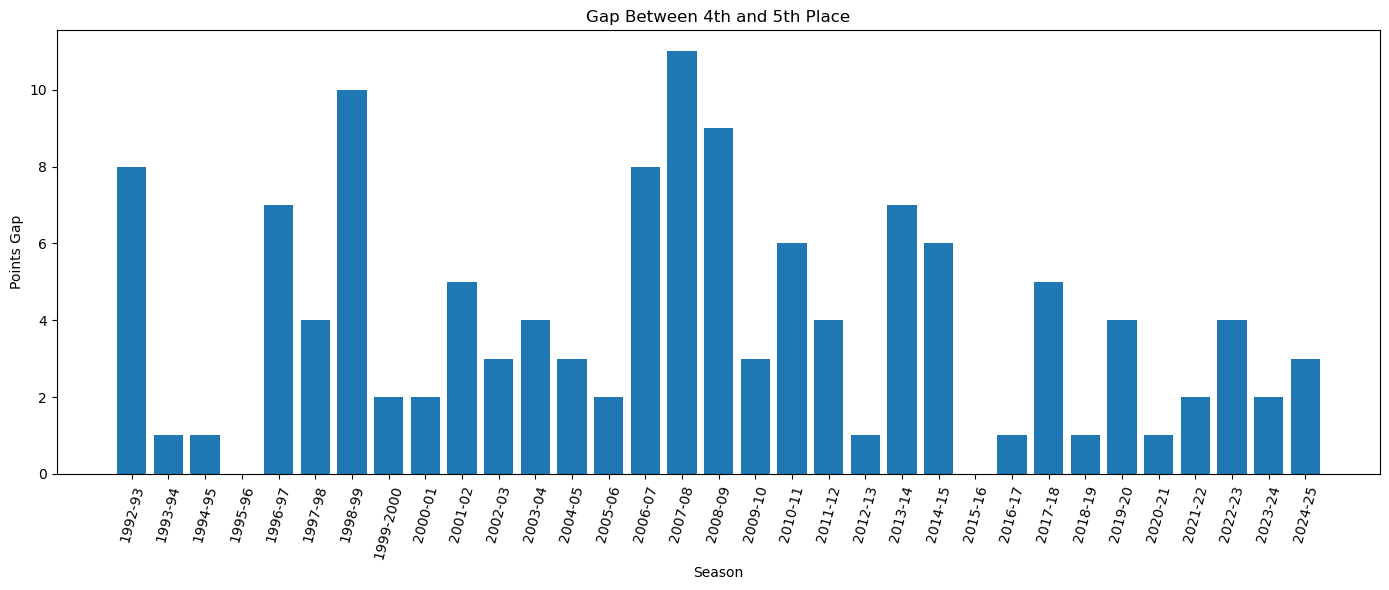

In [13]:

plt.figure(figsize=(14, 6))

plt.bar(top4_metrics["season"], top4_metrics["top4_gap"])

plt.title("Gap Between 4th and 5th Place")
plt.xlabel("Season")
plt.ylabel("Points Gap")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


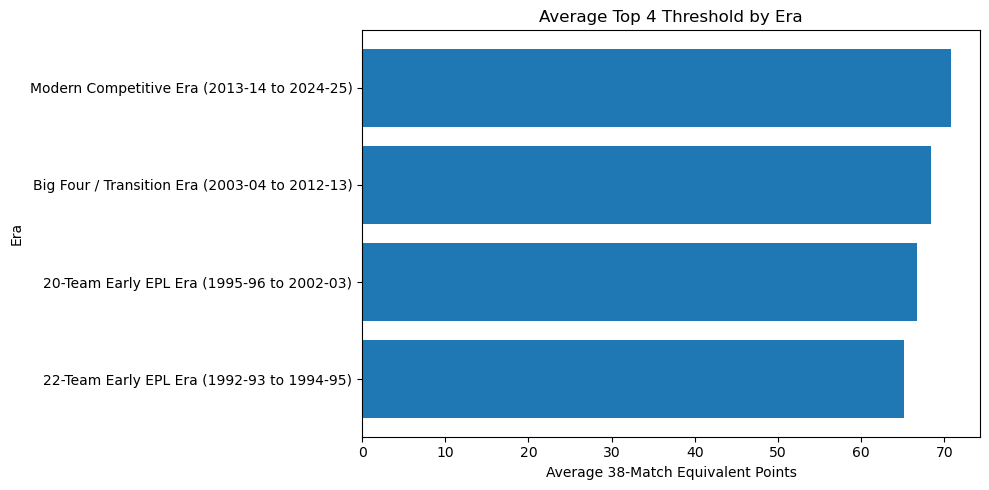

In [14]:

top4_era_plot = top4_era_summary.sort_values("average_top4_38_equivalent")

plt.figure(figsize=(10, 5))

plt.barh(
    top4_era_plot["era"],
    top4_era_plot["average_top4_38_equivalent"]
)

plt.title("Average Top 4 Threshold by Era")
plt.xlabel("Average 38-Match Equivalent Points")
plt.ylabel("Era")
plt.tight_layout()
plt.show()



# 8. Title Race Analysis

## Question

**How close are Premier League title races?**

This section compares:

- Champion points
- Second-place points
- Gap between 1st and 2nd


In [15]:

champions = (
    complete_df[complete_df["pos"] == 1]
    [["season", "team", "pts"]]
    .rename(columns={
        "team": "champion",
        "pts": "champion_points"
    })
)

second_place = (
    complete_df[complete_df["pos"] == 2]
    [["season", "team", "pts"]]
    .rename(columns={
        "team": "second_place_team",
        "pts": "second_place_points"
    })
)

season_metrics = (
    top4_threshold
    .merge(champions, on="season")
    .merge(second_place, on="season")
)

season_metrics["champion_ppg"] = (
    season_metrics["champion_points"] / season_metrics["matches_played"]
)

season_metrics["champion_38_equivalent"] = (
    season_metrics["champion_ppg"] * 38
)

season_metrics["second_place_ppg"] = (
    season_metrics["second_place_points"] / season_metrics["matches_played"]
)

season_metrics["second_place_38_equivalent"] = (
    season_metrics["second_place_ppg"] * 38
)

season_metrics["title_race_gap"] = (
    season_metrics["champion_points"] - season_metrics["second_place_points"]
)

season_metrics["title_race_gap_38_equivalent"] = (
    season_metrics["champion_38_equivalent"] -
    season_metrics["second_place_38_equivalent"]
)

season_metrics.head()


,season,season_start,fourth_place_team,matches_played,top4_points,era,top4_ppg,top4_points_38_equivalent,champion,champion_points,second_place_team,second_place_points,champion_ppg,champion_38_equivalent,second_place_ppg,second_place_38_equivalent,title_race_gap,title_race_gap_38_equivalent
0,1992-93,1992,Blackburn Rovers,42,71,22-Team Early EPL Era (1992-93 to 1994-95),1.690476,64.238095,Manchester United,84,Aston Villa,74,2.000000,76.000000,1.761905,66.952381,10,9.047619
1,1993-94,1993,Arsenal,42,71,22-Team Early EPL Era (1992-93 to 1994-95),1.690476,64.238095,Manchester United,92,Blackburn Rovers,84,2.190476,83.238095,2.000000,76.000000,8,7.238095
2,1994-95,1994,Liverpool,42,74,22-Team Early EPL Era (1992-93 to 1994-95),1.761905,66.952381,Blackburn Rovers,89,Manchester United,88,2.119048,80.523810,2.095238,79.619048,1,0.904762
3,1995-96,1995,Aston Villa,38,63,20-Team Early EPL Era (1995-96 to 2002-03),1.657895,63.000000,Manchester United,82,Newcastle United,78,2.157895,82.000000,2.052632,78.000000,4,4.000000
4,1996-97,1996,Liverpool,38,68,20-Team Early EPL Era (1995-96 to 2002-03),1.789474,68.000000,Manchester United,75,Newcastle United,68,1.973684,75.000000,1.789474,68.000000,7,7.000000



## Title Race Categories

This converts the title race gap into readable categories.


In [16]:

def title_race_category(gap):
    if gap <= 3:
        return "Very Tight"
    elif gap <= 6:
        return "Competitive"
    elif gap <= 10:
        return "Comfortable"
    else:
        return "Dominant"

season_metrics["title_race_category"] = (
    season_metrics["title_race_gap_38_equivalent"]
    .apply(title_race_category)
)

season_metrics[[
    "season", "champion", "champion_points",
    "second_place_team", "second_place_points",
    "title_race_gap", "title_race_category"
]].head()


,season,champion,champion_points,second_place_team,second_place_points,title_race_gap,title_race_category
0,1992-93,Manchester United,84,Aston Villa,74,10,Comfortable
1,1993-94,Manchester United,92,Blackburn Rovers,84,8,Comfortable
2,1994-95,Blackburn Rovers,89,Manchester United,88,1,Very Tight
3,1995-96,Manchester United,82,Newcastle United,78,4,Competitive
4,1996-97,Manchester United,75,Newcastle United,68,7,Comfortable


In [17]:

title_race_era_summary = (
    season_metrics.groupby("era")
    .agg(
        seasons=("season", "count"),
        average_champion_points=("champion_points", "mean"),
        average_champion_38_equivalent=("champion_38_equivalent", "mean"),
        average_second_place_points=("second_place_points", "mean"),
        average_second_place_38_equivalent=("second_place_38_equivalent", "mean"),
        average_title_race_gap=("title_race_gap", "mean"),
        average_title_race_gap_38_equivalent=("title_race_gap_38_equivalent", "mean"),
        smallest_title_gap=("title_race_gap", "min"),
        biggest_title_gap=("title_race_gap", "max")
    )
    .round(2)
    .reset_index()
)

title_race_era_summary


,era,seasons,average_champion_points,average_champion_38_equivalent,average_second_place_points,average_second_place_38_equivalent,average_title_race_gap,average_title_race_gap_38_equivalent,smallest_title_gap,biggest_title_gap
0,20-Team Early EPL Era (1995-96 to 2002-03),8,81.88,81.88,75.25,75.25,6.62,6.62,1,18
1,22-Team Early EPL Era (1992-93 to 1994-95),3,88.33,79.92,82.00,74.19,6.33,5.73,1,10
2,Big Four / Transition Era (2003-04 to 2012-13),10,88.60,88.60,82.20,82.20,6.40,6.40,0,12
3,Modern Competitive Era (2013-14 to 2024-25),12,90.58,90.58,82.67,82.67,7.92,7.92,1,19


In [18]:

title_race_category_by_era = (
    season_metrics.groupby(["era", "title_race_category"])
    .size()
    .reset_index(name="number_of_seasons")
)

title_race_category_by_era


,era,title_race_category,number_of_seasons
0,20-Team Early EPL Era (1995-96 to 2002-03),Comfortable,3
1,20-Team Early EPL Era (1995-96 to 2002-03),Competitive,2
2,20-Team Early EPL Era (1995-96 to 2002-03),Dominant,1
3,20-Team Early EPL Era (1995-96 to 2002-03),Very Tight,2
4,22-Team Early EPL Era (1992-93 to 1994-95),Comfortable,2
5,22-Team Early EPL Era (1992-93 to 1994-95),Very Tight,1
6,Big Four / Transition Era (2003-04 to 2012-13),Comfortable,2
7,Big Four / Transition Era (2003-04 to 2012-13),Competitive,2
8,Big Four / Transition Era (2003-04 to 2012-13),Dominant,3
9,Big Four / Transition Era (2003-04 to 2012-13),Very Tight,3



## Title Race Visualizations


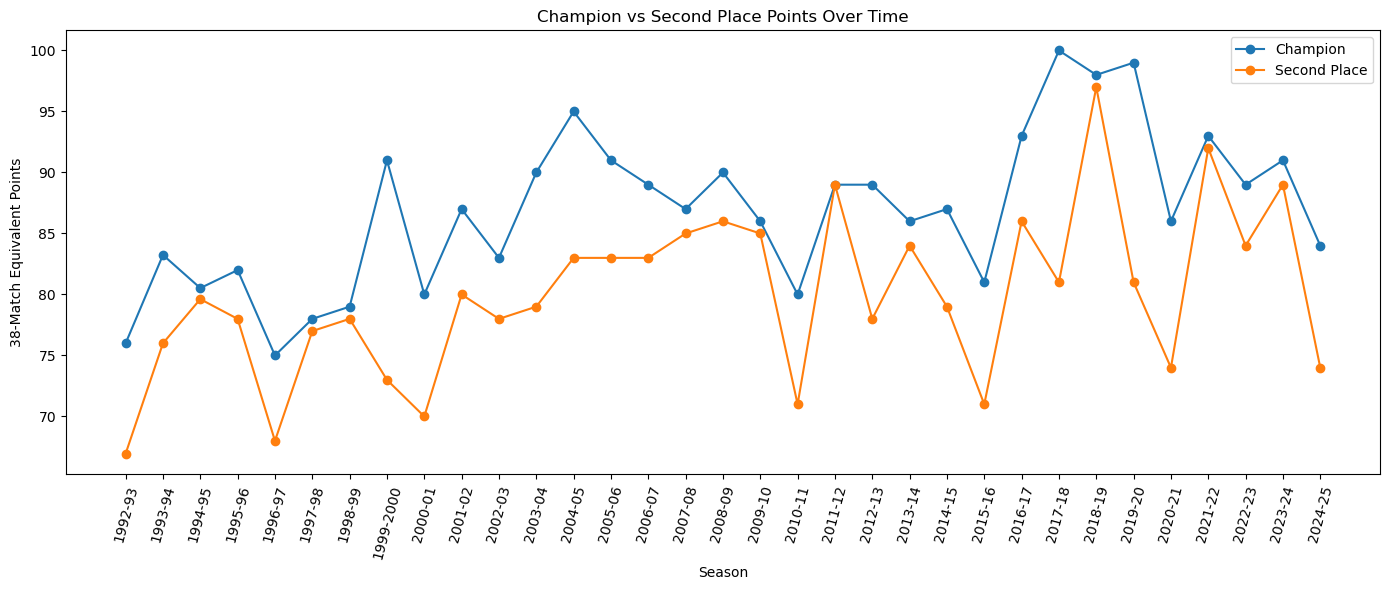

In [19]:

plt.figure(figsize=(14, 6))

plt.plot(
    season_metrics["season"],
    season_metrics["champion_38_equivalent"],
    marker="o",
    label="Champion"
)

plt.plot(
    season_metrics["season"],
    season_metrics["second_place_38_equivalent"],
    marker="o",
    label="Second Place"
)

plt.title("Champion vs Second Place Points Over Time")
plt.xlabel("Season")
plt.ylabel("38-Match Equivalent Points")
plt.xticks(rotation=75)
plt.legend()
plt.tight_layout()
plt.show()


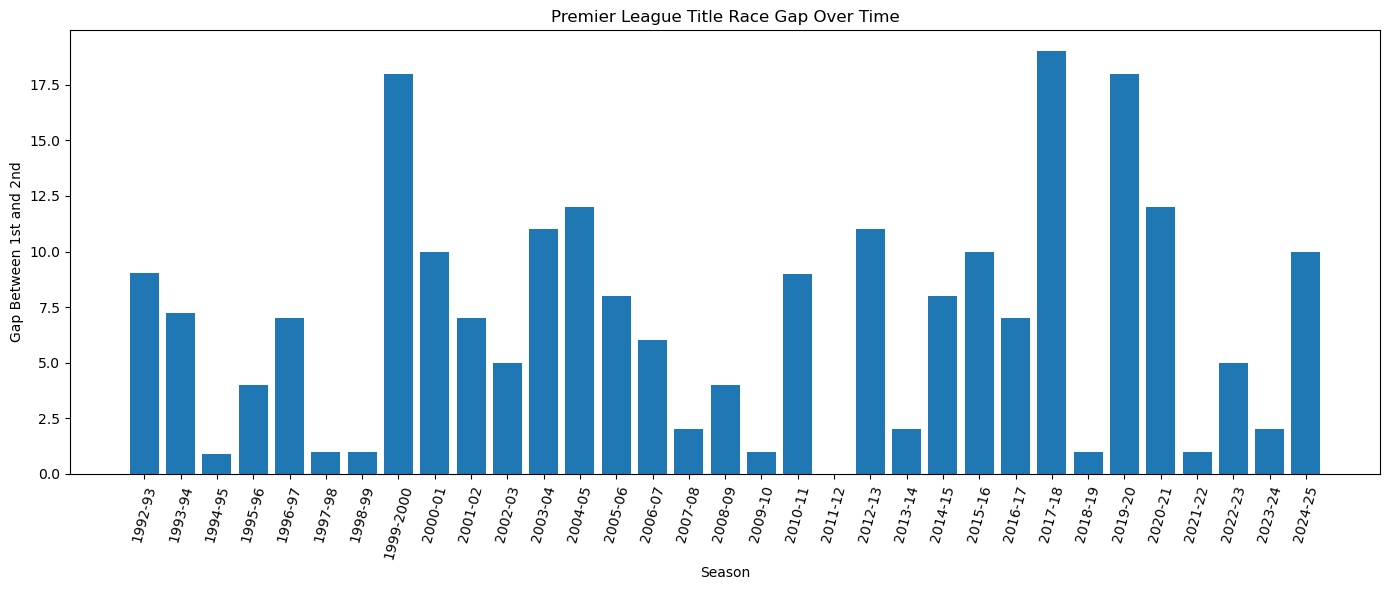

In [20]:

plt.figure(figsize=(14, 6))

plt.bar(
    season_metrics["season"],
    season_metrics["title_race_gap_38_equivalent"]
)

plt.title("Premier League Title Race Gap Over Time")
plt.xlabel("Season")
plt.ylabel("Gap Between 1st and 2nd")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()


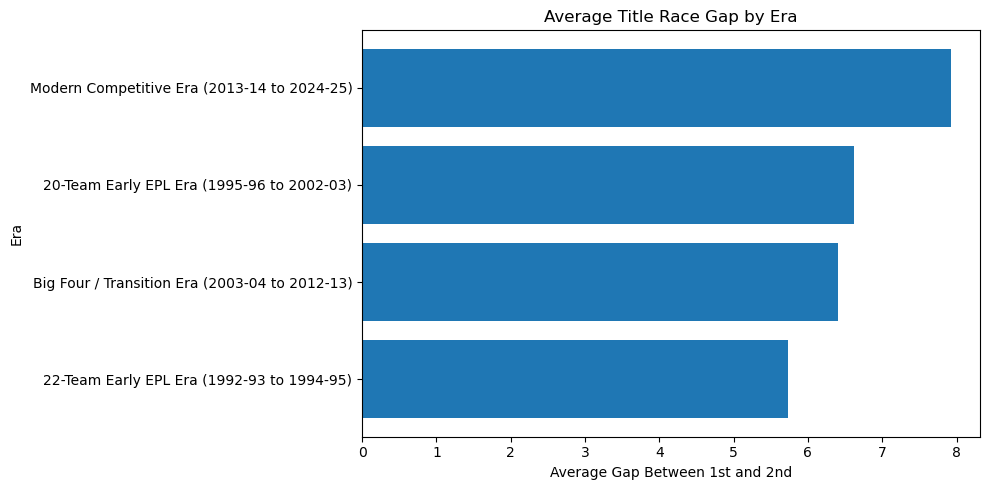

In [21]:

title_gap_plot = title_race_era_summary.sort_values(
    "average_title_race_gap_38_equivalent"
)

plt.figure(figsize=(10, 5))

plt.barh(
    title_gap_plot["era"],
    title_gap_plot["average_title_race_gap_38_equivalent"]
)

plt.title("Average Title Race Gap by Era")
plt.xlabel("Average Gap Between 1st and 2nd")
plt.ylabel("Era")
plt.tight_layout()
plt.show()



# 9. Strong Football Story Tables

These tables are useful for LinkedIn, X, and Power BI.


In [36]:

closest_title_races = (
    season_metrics
    .sort_values("title_race_gap_38_equivalent")
    .head(10)
)

closest_title_races[[
    "season", "champion", "champion_points",
    "second_place_team", "second_place_points",
    "title_race_gap", "title_race_category"
]]


,season,champion,champion_points,second_place_team,second_place_points,title_race_gap,title_race_category
19,2011-12,Manchester City,89,Manchester United,89,0,Very Tight
2,1994-95,Blackburn Rovers,89,Manchester United,88,1,Very Tight
17,2009-10,Chelsea,86,Manchester United,85,1,Very Tight
5,1997-98,Arsenal,78,Manchester United,77,1,Very Tight
6,1998-99,Manchester United,79,Arsenal,78,1,Very Tight
29,2021-22,Manchester City,93,Liverpool,92,1,Very Tight
26,2018-19,Manchester City,98,Liverpool,97,1,Very Tight
21,2013-14,Manchester City,86,Liverpool,84,2,Very Tight
15,2007-08,Manchester United,87,Chelsea,85,2,Very Tight
31,2023-24,Manchester City,91,Arsenal,89,2,Very Tight


In [47]:

most_dominant_title_wins = (
    season_metrics
    .sort_values("title_race_gap_38_equivalent", ascending=False)
    .head(11)
)

most_dominant_title_wins[[
    "season", "champion", "champion_points",
    "second_place_team", "second_place_points",
    "title_race_gap", "title_race_category"
]]


,season,champion,champion_points,second_place_team,second_place_points,title_race_gap,title_race_category
25,2017-18,Manchester City,100,Manchester United,81,19,Dominant
27,2019-20,Liverpool,99,Manchester City,81,18,Dominant
7,1999-2000,Manchester United,91,Arsenal,73,18,Dominant
28,2020-21,Manchester City,86,Manchester United,74,12,Dominant
12,2004-05,Chelsea,95,Arsenal,83,12,Dominant
11,2003-04,Arsenal,90,Chelsea,79,11,Dominant
20,2012-13,Manchester United,89,Manchester City,78,11,Dominant
32,2024-25,Liverpool,84,Arsenal,74,10,Dominant
23,2015-16,Leicester City,81,Arsenal,71,10,Comfortable
8,2000-01,Manchester United,80,Arsenal,70,10,Comfortable


In [41]:

highest_champion_points = (
    season_metrics
    .sort_values("champion_38_equivalent", ascending=False)
    .head(15)
)

highest_champion_points[[
    "season", "champion", "champion_points", "champion_38_equivalent"
]]


,season,champion,champion_points,champion_38_equivalent
25,2017-18,Manchester City,100,100.0
27,2019-20,Liverpool,99,99.0
26,2018-19,Manchester City,98,98.0
12,2004-05,Chelsea,95,95.0
24,2016-17,Chelsea,93,93.0
29,2021-22,Manchester City,93,93.0
31,2023-24,Manchester City,91,91.0
13,2005-06,Chelsea,91,91.0
7,1999-2000,Manchester United,91,91.0
11,2003-04,Arsenal,90,90.0


In [44]:

strongest_runners_up = (
    season_metrics
    .sort_values("second_place_38_equivalent", ascending=False)
    .head(10)
)

strongest_runners_up[[
    "season", "second_place_team", "second_place_points",
    "second_place_38_equivalent", "champion", "champion_points"
]]


,season,second_place_team,second_place_points,second_place_38_equivalent,champion,champion_points
26,2018-19,Liverpool,97,97.0,Manchester City,98
29,2021-22,Liverpool,92,92.0,Manchester City,93
31,2023-24,Arsenal,89,89.0,Manchester City,91
19,2011-12,Manchester United,89,89.0,Manchester City,89
16,2008-09,Liverpool,86,86.0,Manchester United,90
24,2016-17,Tottenham Hotspur,86,86.0,Chelsea,93
17,2009-10,Manchester United,85,85.0,Chelsea,86
15,2007-08,Chelsea,85,85.0,Manchester United,87
21,2013-14,Liverpool,84,84.0,Manchester City,86
30,2022-23,Arsenal,84,84.0,Manchester City,89


In [26]:

champion_by_club = (
    season_metrics.groupby("champion")
    .agg(
        titles=("season", "count"),
        average_champion_points=("champion_38_equivalent", "mean"),
        highest_champion_points=("champion_38_equivalent", "max")
    )
    .round(2)
    .reset_index()
    .sort_values("titles", ascending=False)
)

champion_by_club


,champion,titles,average_champion_points,highest_champion_points
6,Manchester United,13,83.40,91.00
5,Manchester City,8,91.50,100.00
2,Chelsea,5,90.40,95.00
0,Arsenal,3,85.00,90.00
4,Liverpool,2,91.50,99.00
1,Blackburn Rovers,1,80.52,80.52
3,Leicester City,1,81.00,81.00


In [27]:

runner_up_by_club = (
    season_metrics.groupby("second_place_team")
    .agg(
        runner_up_finishes=("season", "count"),
        average_runner_up_points=("second_place_38_equivalent", "mean"),
        highest_runner_up_points=("second_place_38_equivalent", "max")
    )
    .round(2)
    .reset_index()
    .sort_values("runner_up_finishes", ascending=False)
)

runner_up_by_club


,second_place_team,runner_up_finishes,average_runner_up_points,highest_runner_up_points
0,Arsenal,9,77.78,89.00
6,Manchester United,7,81.23,89.00
4,Liverpool,5,87.80,97.00
3,Chelsea,4,79.50,85.00
5,Manchester City,3,79.33,81.00
7,Newcastle United,2,73.00,78.00
1,Aston Villa,1,66.95,66.95
2,Blackburn Rovers,1,76.00,76.00
8,Tottenham Hotspur,1,86.00,86.00



# 10. Relegation Survival Analysis

## Question

**How many points are usually needed to survive relegation?**

For the cleanest relegation analysis, this section uses the 20-team era only:

```text
1995-96 onward
```

That is because from 1995-96, the Premier League consistently had:

- 20 teams
- 38 matches
- 18th, 19th, and 20th as the relegation zone

The key comparison is:

```text
17th vs 18th
```


In [28]:

relegation_df = complete_df[complete_df["season_start"] >= 1995].copy()

survival_threshold = (
    relegation_df[relegation_df["pos"] == 17]
    [["season", "season_start", "team", "pld", "pts", "era"]]
    .rename(columns={
        "team": "survival_team",
        "pld": "matches_played",
        "pts": "survival_points"
    })
    .reset_index(drop=True)
)

first_relegated = (
    relegation_df[relegation_df["pos"] == 18]
    [["season", "team", "pts"]]
    .rename(columns={
        "team": "first_relegated_team",
        "pts": "first_relegated_points"
    })
)

relegation_metrics = (
    survival_threshold
    .merge(first_relegated, on="season")
)

relegation_metrics["survival_ppg"] = (
    relegation_metrics["survival_points"] / relegation_metrics["matches_played"]
)

relegation_metrics["survival_38_equivalent"] = (
    relegation_metrics["survival_ppg"] * 38
)

relegation_metrics["relegation_gap"] = (
    relegation_metrics["survival_points"] -
    relegation_metrics["first_relegated_points"]
)

relegation_metrics["survived_with_40_or_less"] = (
    relegation_metrics["survival_points"] <= 40
)

relegation_metrics.head()


,season,season_start,survival_team,matches_played,survival_points,era,first_relegated_team,first_relegated_points,survival_ppg,survival_38_equivalent,relegation_gap,survived_with_40_or_less
0,1995-96,1995,Southampton,38,38,20-Team Early EPL Era (1995-96 to 2002-03),Manchester City,38,1.000000,38.0,0,True
1,1996-97,1996,Coventry City,38,41,20-Team Early EPL Era (1995-96 to 2002-03),Sunderland,40,1.078947,41.0,1,False
2,1997-98,1997,Everton,38,40,20-Team Early EPL Era (1995-96 to 2002-03),Bolton Wanderers,40,1.052632,40.0,0,True
3,1998-99,1998,Southampton,38,41,20-Team Early EPL Era (1995-96 to 2002-03),Charlton Athletic,36,1.078947,41.0,5,False
4,1999-2000,1999,Bradford City,38,36,20-Team Early EPL Era (1995-96 to 2002-03),Wimbledon,33,0.947368,36.0,3,True


In [29]:

relegation_era_summary = (
    relegation_metrics.groupby("era")
    .agg(
        seasons=("season", "count"),
        average_survival_points=("survival_points", "mean"),
        average_survival_38_equivalent=("survival_38_equivalent", "mean"),
        lowest_survival_points=("survival_points", "min"),
        highest_survival_points=("survival_points", "max"),
        average_relegation_gap=("relegation_gap", "mean"),
        seasons_survived_with_40_or_less=("survived_with_40_or_less", "sum")
    )
    .round(2)
    .reset_index()
)

relegation_era_summary


,era,seasons,average_survival_points,average_survival_38_equivalent,lowest_survival_points,highest_survival_points,average_relegation_gap,seasons_survived_with_40_or_less
0,20-Team Early EPL Era (1995-96 to 2002-03),8,40.25,40.25,36,44,2.88,4
1,Big Four / Transition Era (2003-04 to 2012-13),10,37.10,37.10,34,40,2.20,10
2,Modern Competitive Era (2013-14 to 2024-25),12,36.92,36.92,32,40,4.58,12


In [45]:

closest_relegation_battles = (
    relegation_metrics
    .sort_values("relegation_gap")
    .head(15)
)

closest_relegation_battles[[
    "season", "survival_team", "survival_points",
    "first_relegated_team", "first_relegated_points",
    "relegation_gap"
]]


,season,survival_team,survival_points,first_relegated_team,first_relegated_points,relegation_gap
0,1995-96,Southampton,38,Manchester City,38,0
2,1997-98,Everton,40,Bolton Wanderers,40,0
12,2007-08,Fulham,36,Reading,36,0
11,2006-07,Wigan Athletic,38,Sheffield United,38,0
13,2008-09,Hull City,35,Newcastle United,34,1
9,2004-05,West Bromwich Albion,34,Crystal Palace,33,1
15,2010-11,Wolverhampton Wanderers,40,Birmingham City,39,1
24,2019-20,Aston Villa,35,Bournemouth,34,1
1,1996-97,Coventry City,41,Sunderland,40,1
16,2011-12,Queens Park Rangers,37,Bolton Wanderers,36,1



## Relegation Visualizations


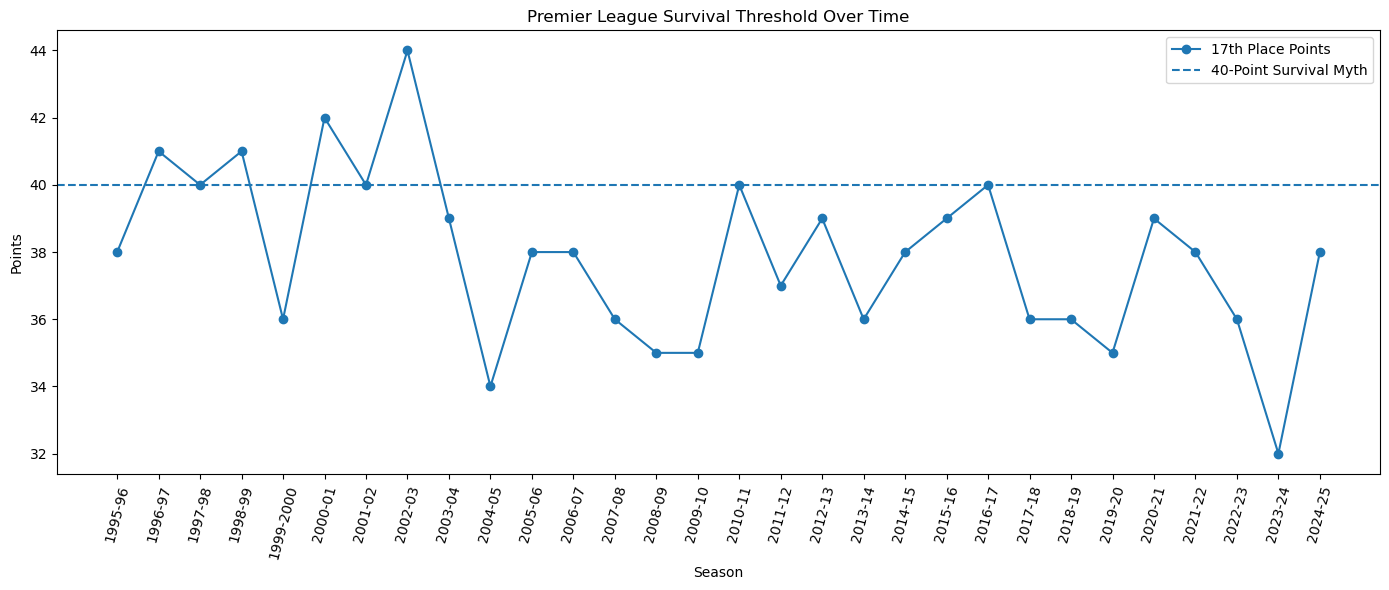

In [31]:

plt.figure(figsize=(14, 6))

plt.plot(
    relegation_metrics["season"],
    relegation_metrics["survival_points"],
    marker="o",
    label="17th Place Points"
)

plt.axhline(
    y=40,
    linestyle="--",
    label="40-Point Survival Myth"
)

plt.title("Premier League Survival Threshold Over Time")
plt.xlabel("Season")
plt.ylabel("Points")
plt.xticks(rotation=75)
plt.legend()
plt.tight_layout()
plt.show()


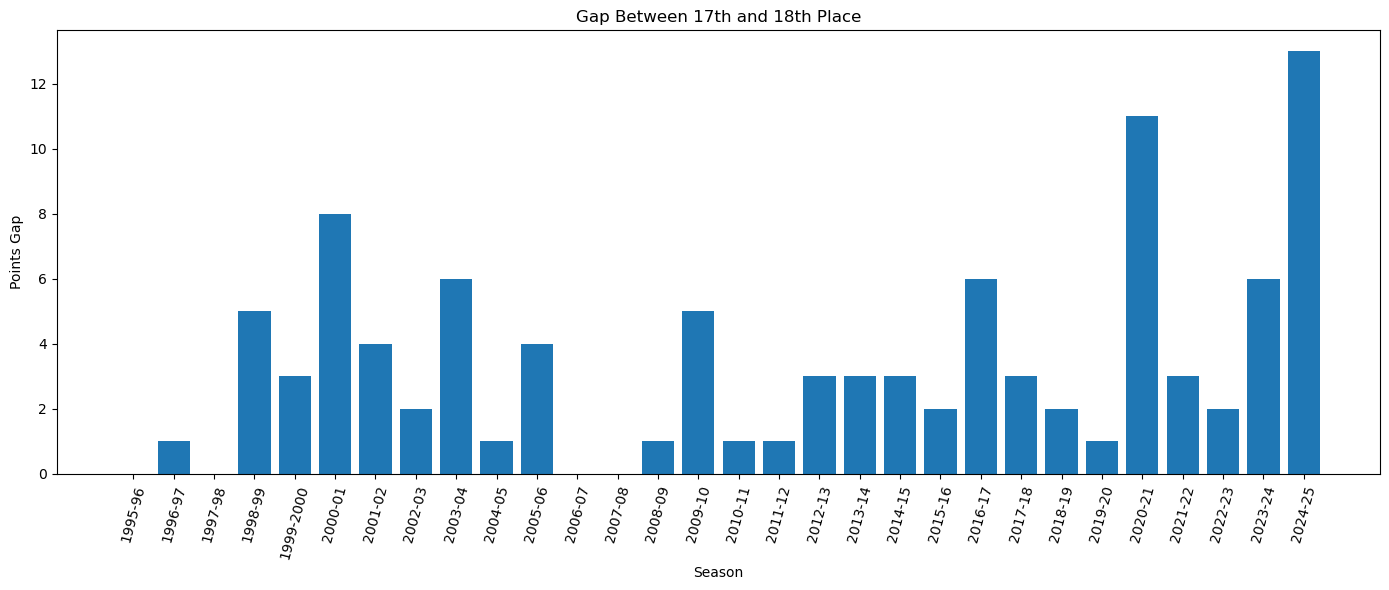

In [32]:

plt.figure(figsize=(14, 6))

plt.bar(
    relegation_metrics["season"],
    relegation_metrics["relegation_gap"]
)

plt.title("Gap Between 17th and 18th Place")
plt.xlabel("Season")
plt.ylabel("Points Gap")
plt.xticks(rotation=75)
plt.tight_layout()
plt.show()



# 11. Overall League Spread

This section checks how wide the league table is.

It compares:

- 1st vs 10th
- 1st vs 20th
- 4th vs 17th


In [33]:

first_place = (
    complete_df[complete_df["pos"] == 1]
    [["season", "pts"]]
    .rename(columns={"pts": "first_place_points"})
)

tenth_place = (
    complete_df[complete_df["pos"] == 10]
    [["season", "pts"]]
    .rename(columns={"pts": "tenth_place_points"})
)

twentieth_place = (
    complete_df[complete_df["pos"] == 20]
    [["season", "pts"]]
    .rename(columns={"pts": "twentieth_place_points"})
)

seventeenth_place = (
    complete_df[complete_df["pos"] == 17]
    [["season", "pts"]]
    .rename(columns={"pts": "seventeenth_place_points"})
)

fourth_place = (
    complete_df[complete_df["pos"] == 4]
    [["season", "pts"]]
    .rename(columns={"pts": "fourth_place_points"})
)

league_spread = (
    first_place
    .merge(tenth_place, on="season")
    .merge(twentieth_place, on="season")
    .merge(seventeenth_place, on="season")
    .merge(fourth_place, on="season")
)

league_spread["top_to_mid_gap"] = (
    league_spread["first_place_points"] -
    league_spread["tenth_place_points"]
)

league_spread["top_to_bottom_gap"] = (
    league_spread["first_place_points"] -
    league_spread["twentieth_place_points"]
)

league_spread["top4_to_survival_gap"] = (
    league_spread["fourth_place_points"] -
    league_spread["seventeenth_place_points"]
)

league_spread.head()


,season,first_place_points,tenth_place_points,twentieth_place_points,seventeenth_place_points,fourth_place_points,top_to_mid_gap,top_to_bottom_gap,top4_to_survival_gap
0,1992-93,84,56,49,51,71,28,35,20
1,1993-94,92,57,42,44,71,35,50,27
2,1994-95,89,54,43,49,74,35,46,25
3,1995-96,82,51,29,38,63,31,53,25
4,1996-97,75,46,34,41,68,29,41,27



# 12. Export Tables for Power BI

These CSV files can be imported into Power BI for dashboard creation.


In [34]:

top4_metrics.to_csv("top4_metrics.csv", index=False)
top4_era_summary.to_csv("top4_era_summary.csv", index=False)

season_metrics.to_csv("season_metrics.csv", index=False)
title_race_era_summary.to_csv("title_race_era_summary.csv", index=False)
title_race_category_by_era.to_csv("title_race_category_by_era.csv", index=False)

closest_title_races.to_csv("closest_title_races.csv", index=False)
most_dominant_title_wins.to_csv("most_dominant_title_wins.csv", index=False)
highest_champion_points.to_csv("highest_champion_points.csv", index=False)
strongest_runners_up.to_csv("strongest_runners_up.csv", index=False)
champion_by_club.to_csv("champion_by_club.csv", index=False)
runner_up_by_club.to_csv("runner_up_by_club.csv", index=False)

relegation_metrics.to_csv("relegation_metrics.csv", index=False)
relegation_era_summary.to_csv("relegation_era_summary.csv", index=False)
closest_relegation_battles.to_csv("closest_relegation_battles.csv", index=False)

league_spread.to_csv("league_spread.csv", index=False)

print("Export complete.")


Export complete.



# 13. Suggested Power BI Dashboard Pages

## Page 1: Top 4 Race
- Top 4 threshold over time
- Average Top 4 threshold by era
- Gap between 4th and 5th place

## Page 2: Title Race
- Champion vs second-place points
- Title race gap over time
- Average title race gap by era
- Closest title races
- Most dominant title wins
- Strongest runners-up
- Clubs with most runner-up finishes

## Page 3: Relegation Battle
- Survival threshold over time
- 40-point survival check
- Gap between 17th and 18th
- Average survival points by era
- Closest relegation battles

## Page 4: League Spread
- 1st vs 10th gap
- 1st vs 20th gap
- 4th vs 17th gap



# 14. Project Summary

This project analyzes Premier League competitiveness using historical league table data.

The strongest insights come from three key areas:

1. **Title Race** — how close champions and runners-up were  
2. **Top 4 Race** — how difficult Champions League qualification became  
3. **Relegation Survival** — how many points teams needed to avoid relegation  

The analysis also corrects for early 42-match seasons by using 38-match equivalent points.
